<a href="https://colab.research.google.com/github/DeepsaranNS/AI-Engineering-Roadmap/blob/main/Phase_2_MNIST_Digit_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# 1. Load the MNIST dataset (handwritten digits)
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. Scale the pixel values to be between 0 and 1
x_train = x_train / 255.0
x_test = x_test / 255.0

# 3. Build the Neural Network Architecture
model = Sequential([
    Flatten(input_shape=(28, 28)),      # Input Layer
    Dense(128, activation='relu'),      # Hidden Layer
    Dense(10, activation='softmax')     # Output Layer
])

# 4. Print the blueprint of our brain
print("--- NEURAL NETWORK BLUEPRINT ---")
model.summary()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- NEURAL NETWORK BLUEPRINT ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [2]:
# 1. Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 2. Train the model!
print("--- COMMENCING NEURAL NETWORK TRAINING ---")
history = model.fit(x_train, y_train, epochs=5)

--- COMMENCING NEURAL NETWORK TRAINING ---
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9265 - loss: 0.2560
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9675 - loss: 0.1099
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9774 - loss: 0.0745
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9826 - loss: 0.0558
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9869 - loss: 0.0427


In [3]:
# 1. Evaluate the model on the unseen test data
print("--- FINAL EXAM: UNSEEN DATA ---")
test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)

# 2. Print the final grade
print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")


--- FINAL EXAM: UNSEEN DATA ---
313/313 - 1s - 3ms/step - accuracy: 0.9761 - loss: 0.0731

Final Test Accuracy: 97.61%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


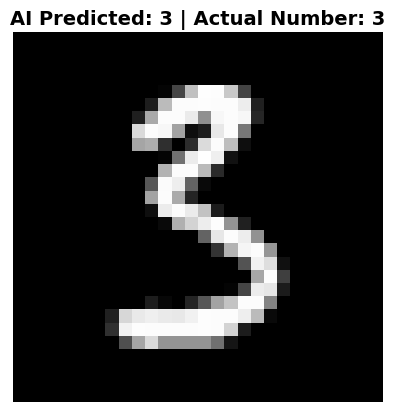

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Pick a random image from our unseen test data
image_index = 890  # Can give the Random index in our dataset!
test_image = x_test[image_index]
actual_label = y_test[image_index]

# 2. Reshape the image so the network can read it (it expects a batch, so we give it a batch of 1)
image_batch = np.expand_dims(test_image, axis=0)

# 3. Ask the neural network to predict what number this is
predictions = model.predict(image_batch)
predicted_label = np.argmax(predictions)

# 4. Display the image and the AI's prediction
plt.imshow(test_image, cmap='gray')
plt.title(f"AI Predicted: {predicted_label} | Actual Number: {actual_label}", fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()
